# **Technical Note: Decision Trees**

## **Business Case Introduction**
Universal Bank is seeking to improve the targeting of its **personal loan campaigns** by identifying which customers are most likely to accept a loan offer. The bank has collected detailed information on 5,000 existing customers, including demographic characteristics (such as age, income, family size, and education level) and behavioral attributes (such as credit card usage, mortgage balance, and whether the customer holds accounts like certificates of deposit or investment securities). Given the relatively low acceptance rate of previous offers, the bank aims to build a predictive model that can segment customers based on their likelihood of loan acceptance. A **decision tree** is a valuable tool for this task, as it produces an interpretable set of rules that can guide marketing decisions and customer outreach strategies.

**Objective**
- Use a decision tree model to predict whether a customer accepts a personal loan (`PersonalLoan`) based on demographic and financial attributes.

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
bank = pd.read_csv("../Datasets/UniversalBank.csv")
bank

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


### **Step 0: Preprocessing**

In [2]:
bank.describe(include="all")

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [3]:
# Replace negative Experience values with NA
bank['Experience'] = np.where(bank['Experience'] < 0, np.nan, bank['Experience'])

# Impute missing Experiences with median
bank['Experience'] = np.where(bank['Experience'].isna(), bank['Experience'].median(), bank['Experience'])

# Convert Education and Family using explicit level labels
bank['Education'] = pd.Categorical(bank['Education'].map({1:"Undergraduate", 2:"Graduate", 3:"Advanced"}),
                                   categories=["Undergraduate","Graduate","Advanced"],
                                   ordered=True)

bank['Family'] = pd.Categorical(bank['Family'].map({1:"Single", 2:"Couple", 3:"3 members", 4:"4+ members"}),
                                categories=["Single","Couple","3 members","4+ members"],
                                ordered=True)

# Convert the target variable to a category (try not to convert binary vairables into categories because it could bring redundant 
# information to the model when applying one-hot)
bank['PersonalLoan'] = bank['PersonalLoan'].astype("category")

# Drop ID and ZIP code
bank.drop(columns=['ID','ZIP Code'], axis=1, inplace=True)

bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                5000 non-null   int64   
 1   Experience         5000 non-null   float64 
 2   Income             5000 non-null   int64   
 3   Family             5000 non-null   category
 4   CCAvg              5000 non-null   float64 
 5   Education          5000 non-null   category
 6   Mortgage           5000 non-null   int64   
 7   PersonalLoan       5000 non-null   category
 8   SecuritiesAccount  5000 non-null   int64   
 9   CDAccount          5000 non-null   int64   
 10  Online             5000 non-null   int64   
 11  CreditCard         5000 non-null   int64   
dtypes: category(3), float64(2), int64(7)
memory usage: 366.8 KB


### **Step 1: Exploratory Data Analysis**

In [4]:
# Class balance
bank['PersonalLoan'].value_counts()

PersonalLoan
0    4520
1     480
Name: count, dtype: int64

In [5]:
bank['PersonalLoan'].value_counts(normalize=True)

PersonalLoan
0    0.904
1    0.096
Name: proportion, dtype: float64

The output reveals a **class imbalance** in the `PersonalLoan` variable:
- Only **480 out of 5000 customers (9.6%)** accepted a personal loan.
- The vast majority (**4520 customers, or 90.4%**) did not.

**Why this matters:**
- **Standard decision trees** may favor predicting the majority class (0) to maximize accuracy.
- This could result in high overall accuracy but poor **recall** and **precision** for the majority class (loan acceptance).

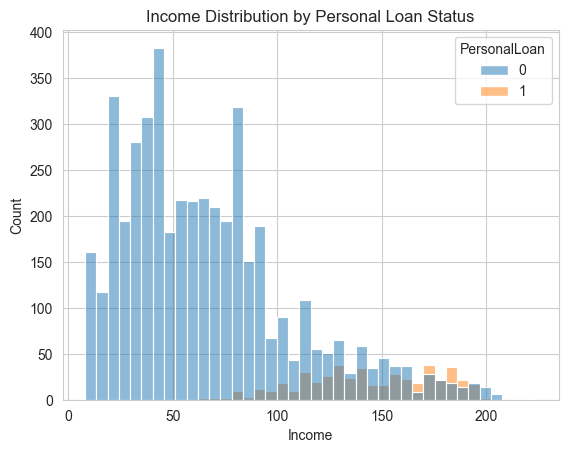

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram: Income by Loan Status
sns.set_style('whitegrid')
sns.histplot(data=bank, x='Income', hue='PersonalLoan', bins=40)
plt.title("Income Distribution by Personal Loan Status")
plt.show()

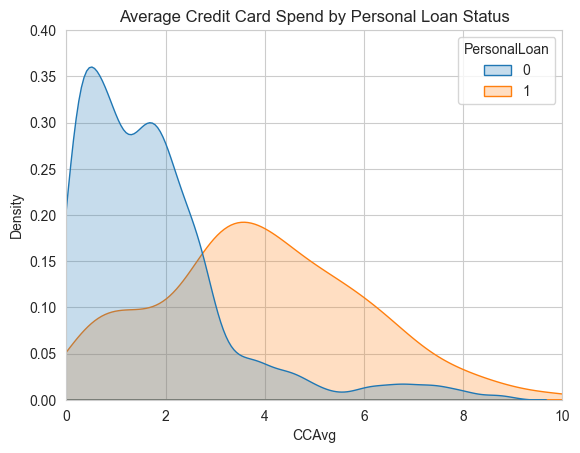

In [7]:
# Density: CCAvg by Loan Status
sns.kdeplot(data=bank, x='CCAvg', hue='PersonalLoan', fill=True, common_norm=False)
plt.title("Average Credit Card Spend by Personal Loan Status")
plt.xlim(0,10)
plt.ylim(0,0.4)
plt.show()

In [8]:
import plotly.express as px

# Proportion bar chart: Education level
# Calcular proporciones manualmente
df_prop = (bank.groupby(["Education", "PersonalLoan"]).size().reset_index(name="count"))

# Calcular proporción dentro de cada nivel educativo
df_prop["proportion"] = (df_prop.groupby("Education")["count"].transform(lambda x: x / x.sum()))

fig = px.bar(df_prop, x="Education", y="proportion", color="PersonalLoan", barmode="stack", title="Loan Acceptance by Education Level",
             labels={"proportion": "Proportion Accepted"})
fig.update_layout(yaxis=dict(tickformat=".0%"), legend_title="Personal Loan")

fig.write_html("Loan_Acceptance_by_Education.html", include_plotlyjs="full")
fig.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9092\2938525414.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_prop = (bank.groupby(["Education", "PersonalLoan"]).size().reset_index(name="count"))
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9092\2938525414.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_prop["proportion"] = (df_prop.groupby("Education")["count"].transform(lambda x: x / x.sum()))


### **Step 2: Stratified Train/Test Split**

In [9]:
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility and create a stratified train-test split (70% train, 30% test) based on PersonalLoan class
train, test = train_test_split(bank, test_size=0.3, stratify=bank['PersonalLoan'], random_state=123)

# Check class distribution (proportion of 0s and 1s) in the training set
train['PersonalLoan'].value_counts(normalize=True)

PersonalLoan
0    0.904
1    0.096
Name: proportion, dtype: float64

In [10]:
# Check class distribution (proportion of 0s and 1s) in the test set
test['PersonalLoan'].value_counts(normalize=True)

PersonalLoan
0    0.904
1    0.096
Name: proportion, dtype: float64

### **Step 3: Apply SMOTE to Training Set**
We apply **SMOTE (Synthetic Minority Oversampling Technique)** to address **class imbalance** in the PersonalLoan variable.
- `step_smote()` expects the target variable to be a factor with 2 levels (minority and majority classes).

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

# Target is PersonalLoan, use all the other variables as predictors
X_train = train.drop(columns=['PersonalLoan'])
Y_train = train['PersonalLoan']

# Identify the names of the numeric and categorical columns
categorical_cols = X_train.select_dtypes(include=['object','category']).columns
numeric_cols = X_train.select_dtypes(exclude=['object','category']).columns

# One-hot encoding for the categorical columns, passthrough for numerics
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols), 
                                               ('num', 'passthrough', numeric_cols)])

# Adjust and transform the categorical variables (one-hot)
X_train_encoded = preprocessor.fit_transform(X_train)

# Apply SMOTE
smote = SMOTE(random_state=123)
X_train_smoted, Y_train_smoted = smote.fit_resample(X_train_encoded, Y_train)

# Check class balance after applying smote
Y_train_smoted.value_counts(normalize=True)

PersonalLoan
0    0.5
1    0.5
Name: proportion, dtype: float64

The original training data is **imbalanced:**
- Only about **9.6%** of customers accepted a loan (`PersonalLoan = 1`)
- Most customers belong to the majority class (`PersonalLoan = 0`)

➡️ **Problem:** Standard models (like decision trees) may learn to always predict class “0” just to improve accuracy — ignoring the minority class, which is the class we actually care about identifying (loan takers).

**How does SMOTE work?**

- Creates **synthetic examples** of the minority class (`PersonalLoan = 1`)
- These new examples are generated by interpolating between existing ones (not by copying them)
- This results in a **balanced training dataset**, with a 50/50 class split

**What the code does:**

1. **Defines a recipe:**

    ```python
    X_train = train.drop(columns=['PersonalLoan'])
    Y_train = train['PersonalLoan']
    ```

    This says: use all variables to predict `PersonalLoan`.

2. **Applies two steps in the recipe:**

    - `step_dummy()` – converts all categorical predictors to binary dummy variables
    - `step_smote()` – applies SMOTE to the training data

3. **Prepares and applies the recipe:**

    - `prep(rec)` learns how to preprocess the training data
    - `juice(rec_prep)` applies these transformations and gives the final **SMOTED** training set

4. **Final check:**

    ```python
    Y_train_smoted.value_counts(normalize=True)
    ```
    Confirms that the new training data now has a balanced class distribution:

### **Step 4: Train Decision Tree Model**
In this step, we build a deep decision tree using the SMOTED (balanced) training dataset. The goal is to explore the model’s full complexity and identify key patterns before pruning.

1. **Train a Deep Classification Tree**

Number of nodes: 111
Maximum depth: 12


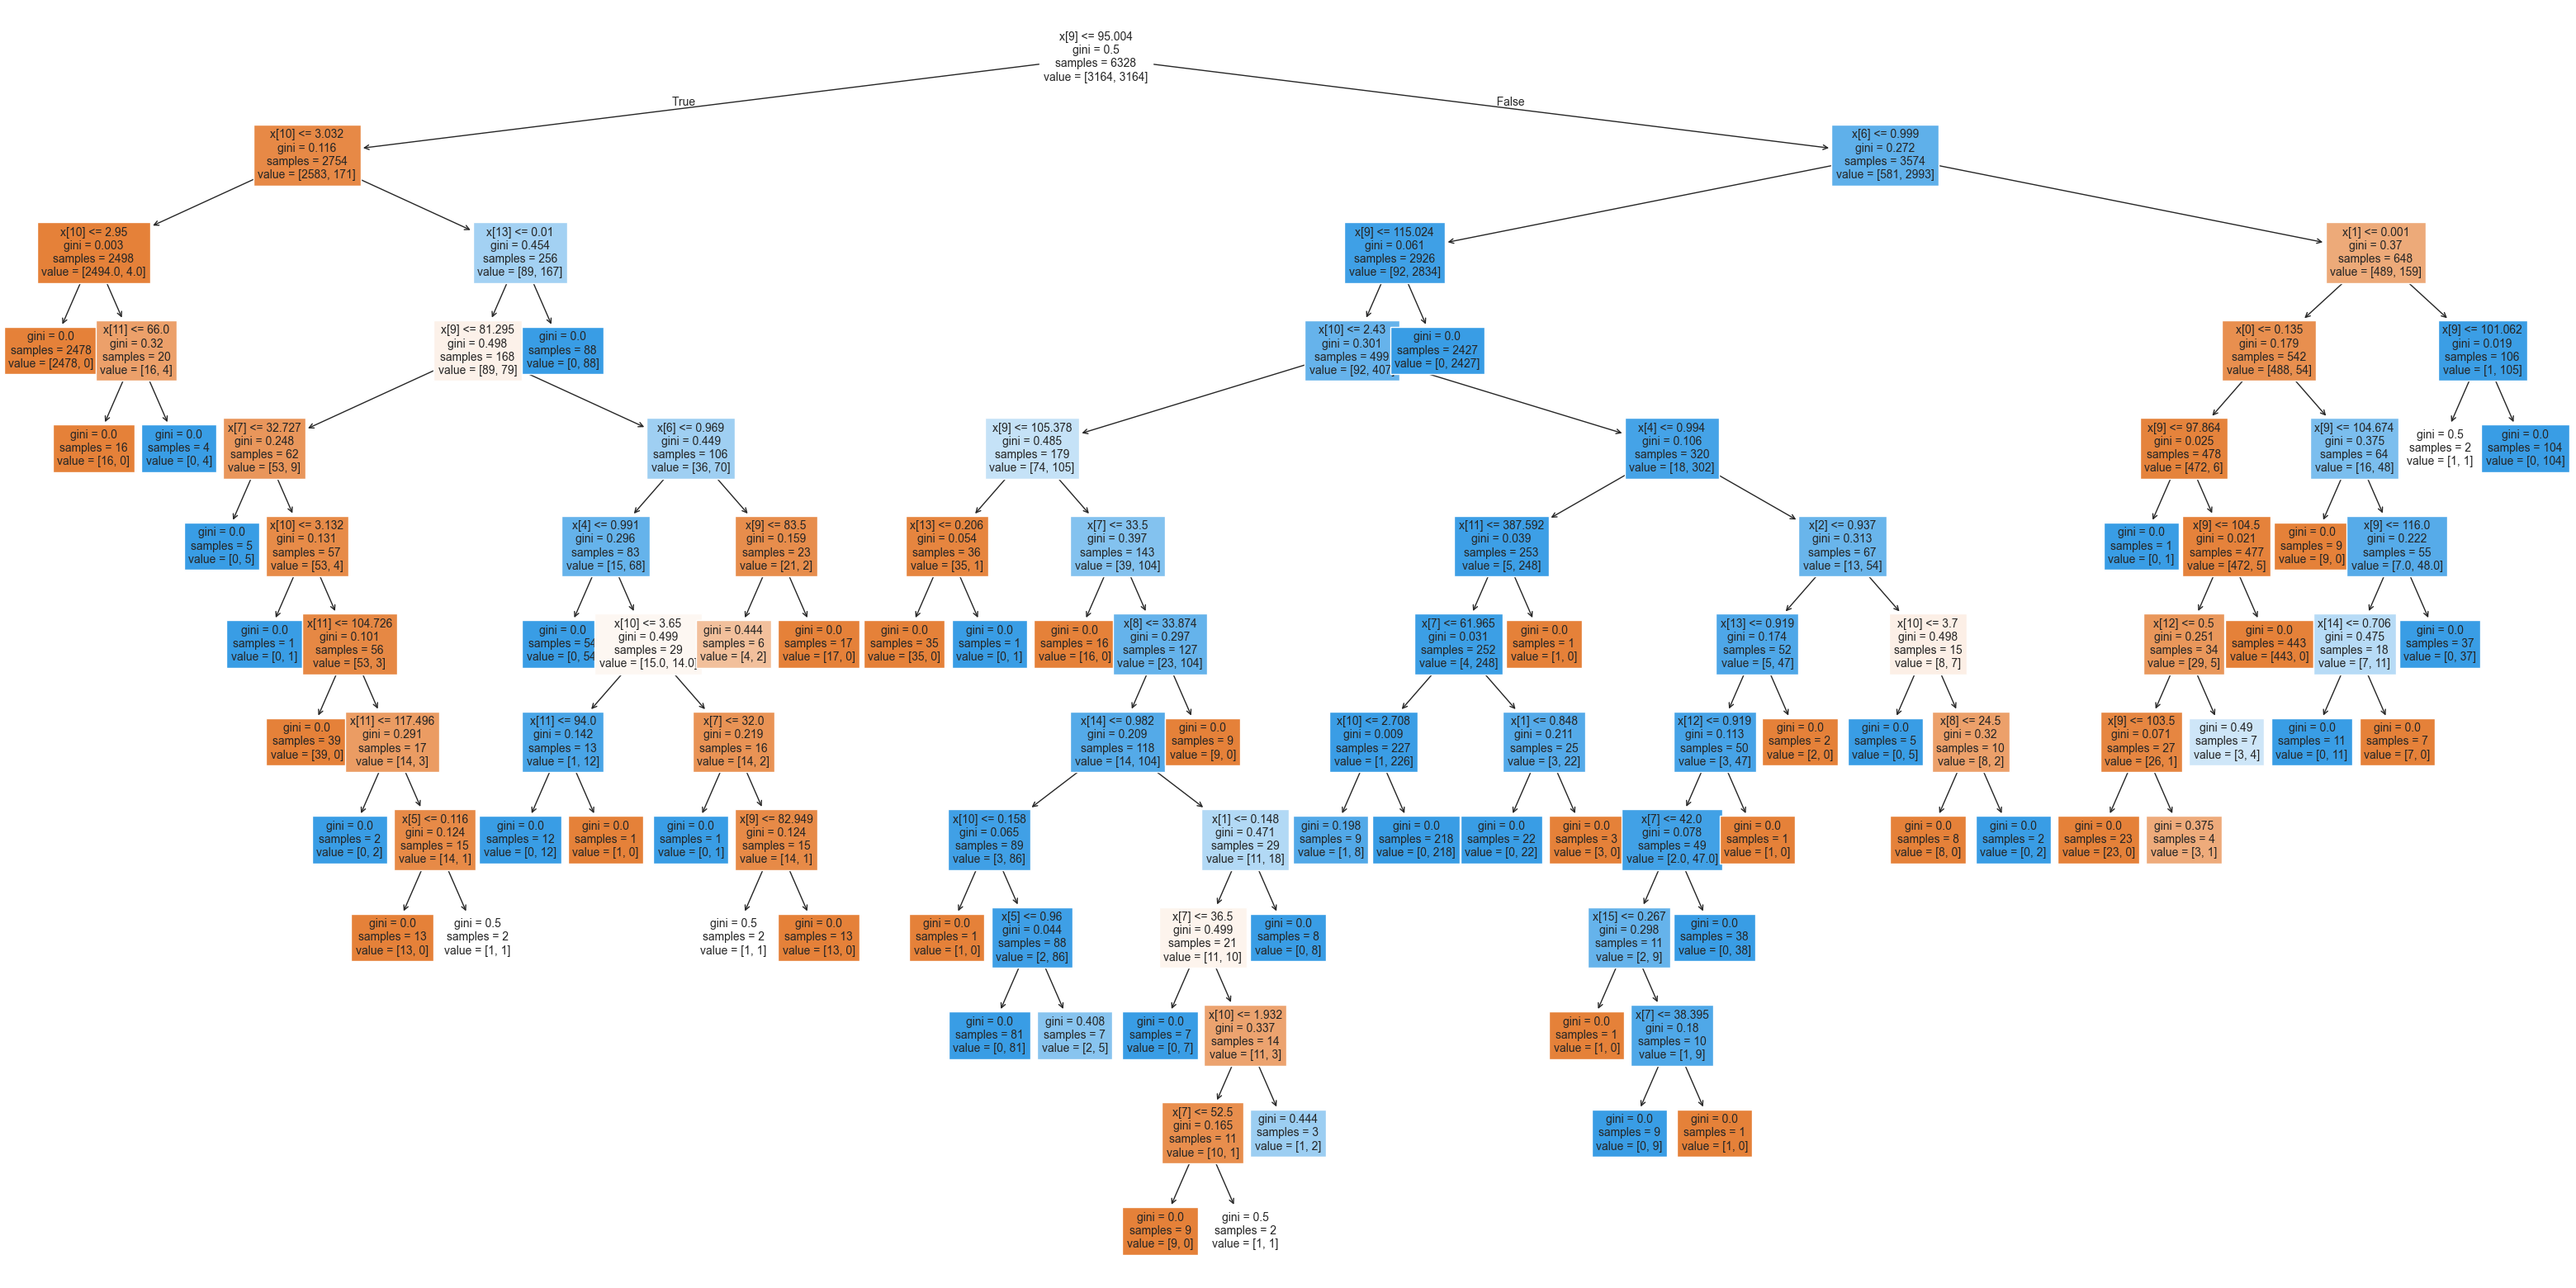

In [12]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_deep = DecisionTreeClassifier(
    criterion='gini', # Clasification task
    min_samples_split=10, # Minimum number of observations required to split a node
    ccp_alpha=0, # No pre-prunning; grow the full tree
    random_state=123
)

# Adjust the model with the SMOTED dataset
tree_deep.fit(X_train_smoted, Y_train_smoted)

# Visualize the structure of the three
print(f"Number of nodes: {tree_deep.tree_.node_count}")
print(f"Maximum depth: {tree_deep.tree_.max_depth}")

# Visualize the form of the three
plt.figure(figsize=(40,20))
plot_tree(tree_deep, filled=True, fontsize=10)
plt.show()

**Reminder: Compared to R, Python brings us fewer of nodes (6328 vs 111) and the maximum of depth (12) is smaller due to the way both language understand parameters even if they have the same values.**

We deliberately allow the tree to grow without restrictions (`ccp_alpha = 0`) to observe all possible data splits and interaction patterns. This deep tree serves as a baseline before pruning.

**Explanation of `DecisionTreeClassifier()` arguments:**

- **`Y_train_smoted`**: Use all variables to predict the loan acceptance outcome.
- **`X_train_smoted`**: The SMOTEd dataset ensures balanced classes.
- **`criterion = "gini"`**: Indicates this is a classification task using gini method.
- **`ccp_alpha = 0`**: Disables early pruning to build the full tree.
- **`min_samples_split = 10`**: Requires at least 10 observations to attempt a split.

2. **Count Terminal Nodes**

In [13]:
# Number of terminal (leaf) nodes in the tree
sum(tree_deep.tree_.children_left == -1)

np.int64(56)

This counts the number of distinct paths in the tree. A large number of terminal nodes suggests the model may be overly complex.

3. **Inspect Splitting Variables**

In [14]:
# Get the index of the variables used:
idx = tree_deep.tree_.feature[tree_deep.tree_.feature != -2]

# Get preprocessor names:
pre_proc = preprocessor.get_feature_names_out()

# Names of the variables used:
split = pre_proc[idx]

# Number of variables used:
num_var = len(np.unique(split))

print(f"Number of variables used: {num_var}")
print(f"Variables used: ",np.unique(split))

Number of variables used: 15
Variables used:  ['cat__Education_Advanced' 'cat__Education_Graduate'
 'cat__Education_Undergraduate' 'cat__Family_3 members'
 'cat__Family_4+ members' 'cat__Family_Couple' 'num__Age' 'num__CCAvg'
 'num__CDAccount' 'num__CreditCard' 'num__Experience' 'num__Income'
 'num__Mortgage' 'num__Online' 'num__SecuritiesAccount']


We obtained different variables if we compare them with the results shown in R

4. **Visualize the Tree**

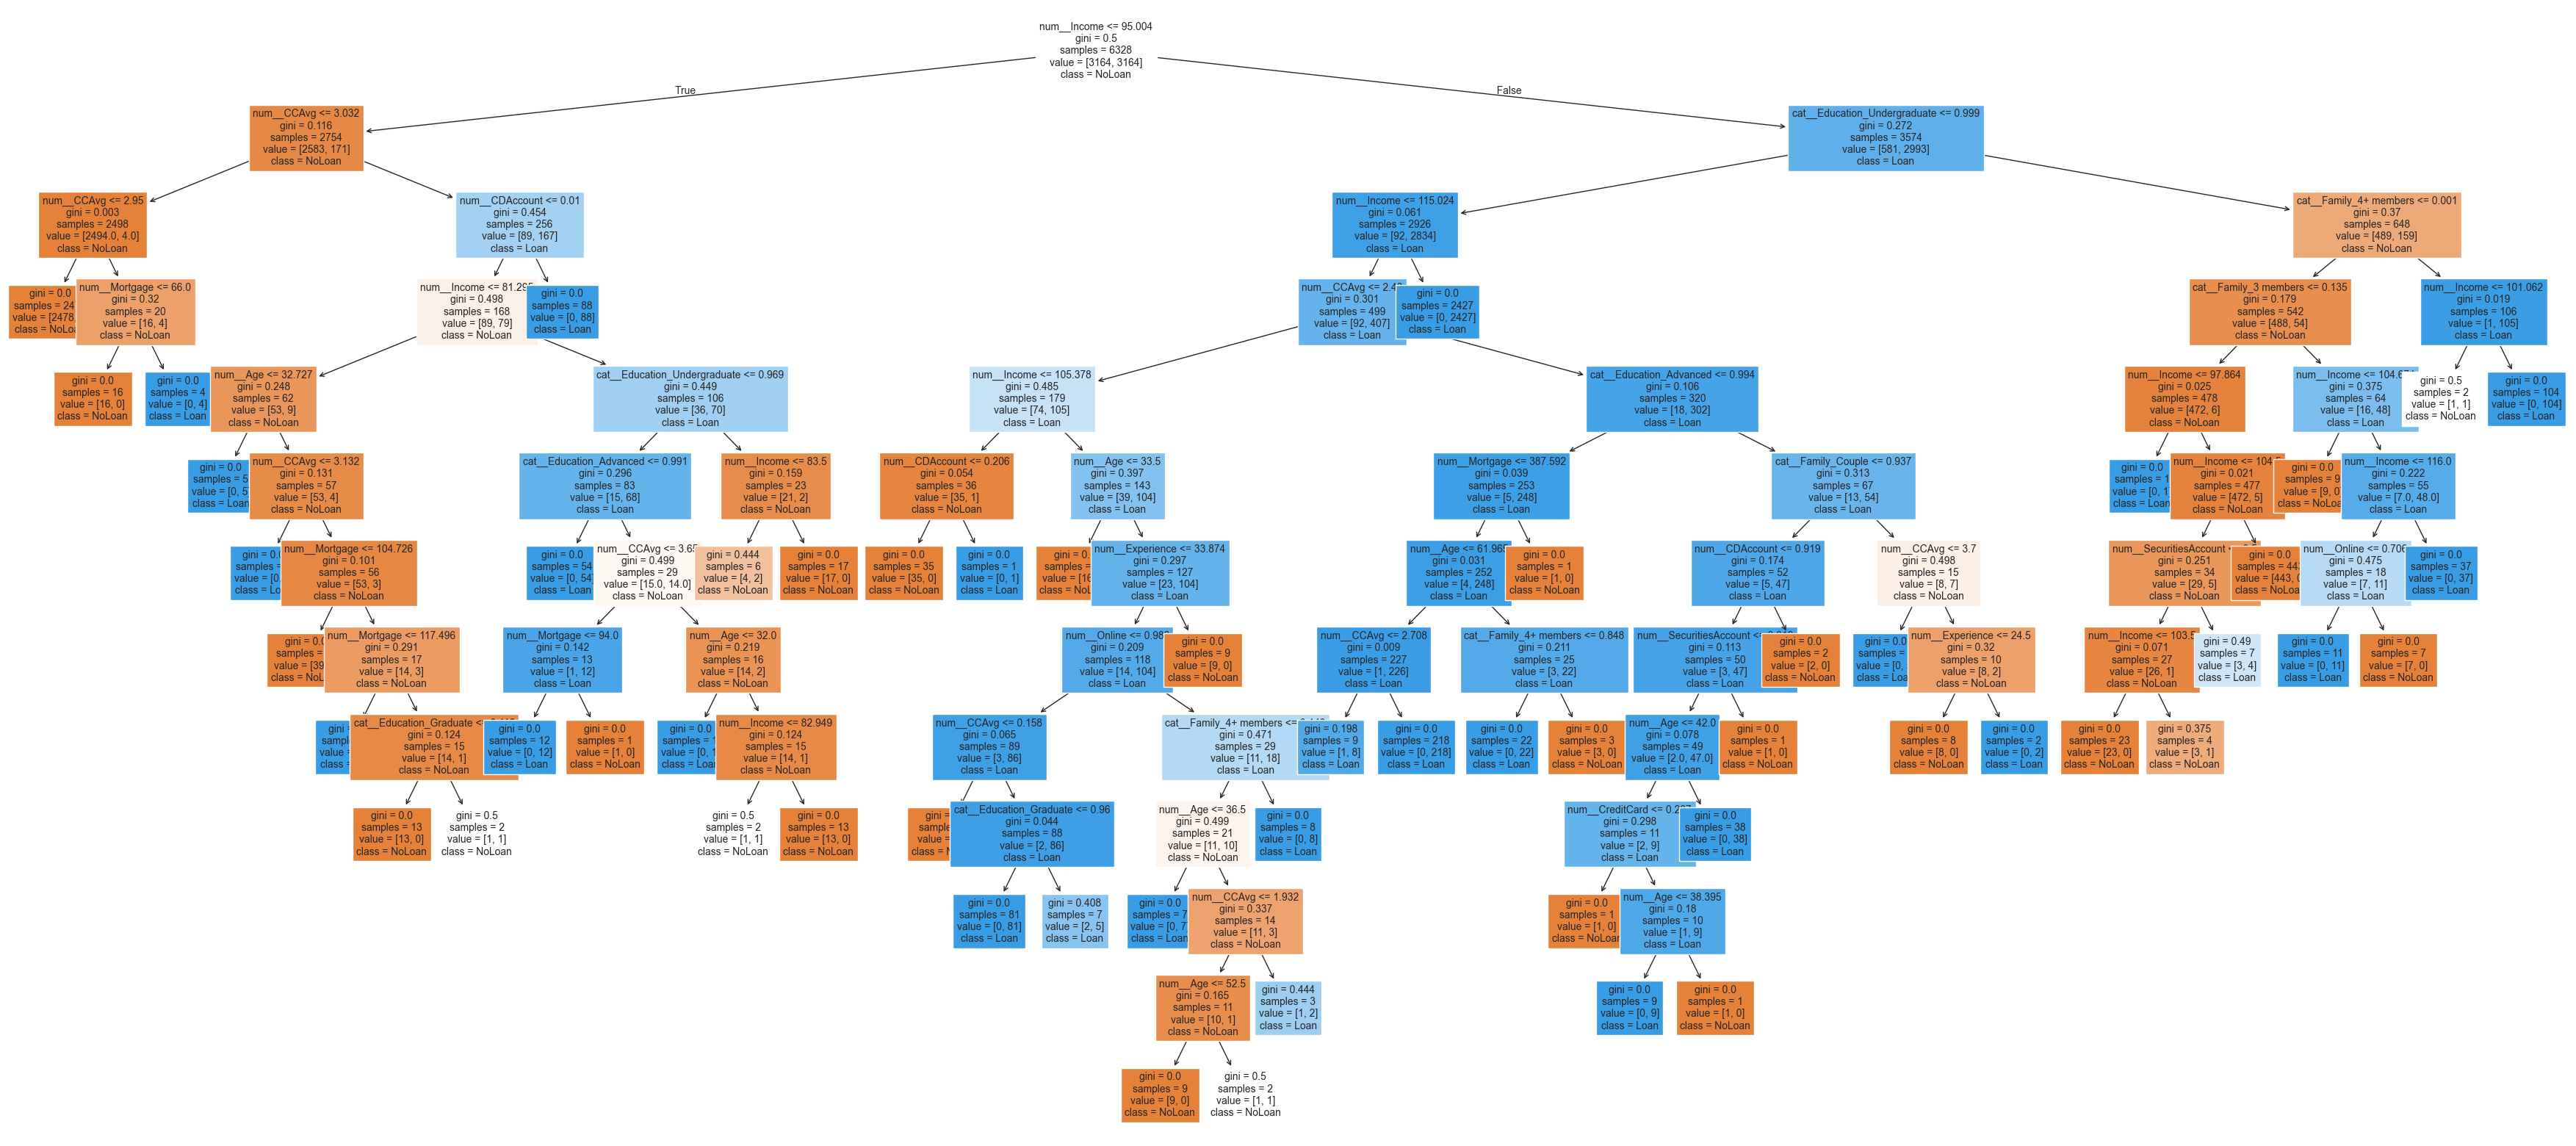

In [15]:
plt.figure(figsize=(45,20))
plot_tree(tree_deep, filled=True, fontsize=10, feature_names=preprocessor.get_feature_names_out(),
          class_names=['NoLoan','Loan'])
plt.show()

In [16]:
from sklearn.tree import export_text
print(export_text(tree_deep, feature_names=list(preprocessor.get_feature_names_out())))

|--- num__Income <= 95.00
|   |--- num__CCAvg <= 3.03
|   |   |--- num__CCAvg <= 2.95
|   |   |   |--- class: 0
|   |   |--- num__CCAvg >  2.95
|   |   |   |--- num__Mortgage <= 66.00
|   |   |   |   |--- class: 0
|   |   |   |--- num__Mortgage >  66.00
|   |   |   |   |--- class: 1
|   |--- num__CCAvg >  3.03
|   |   |--- num__CDAccount <= 0.01
|   |   |   |--- num__Income <= 81.29
|   |   |   |   |--- num__Age <= 32.73
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- num__Age >  32.73
|   |   |   |   |   |--- num__CCAvg <= 3.13
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- num__CCAvg >  3.13
|   |   |   |   |   |   |--- num__Mortgage <= 104.73
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- num__Mortgage >  104.73
|   |   |   |   |   |   |   |--- num__Mortgage <= 117.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- num__Mortgage >  117.50
|   |   |   |   |   |   |   |   |--- cat__Education_Graduate <= 0.12

**How to Read the Tree**

Each **node (box)** in the tree displays:

- **Predicted class**
    - 0 = customer predicted to decline the loan
    - 1 = customer predicted to accept the loan
- **Class probability**
    - The model’s confidence in the predicted class at that node
- **Proportion of training data**
    - % of observations that reached that point in the tree

🔹 Root Split: Income as the Primary Predictor

- The top-level decision rule is **`Income < 95`**, which serves as the **root split.**

- Interpretation:
    - Customers earning **less than $95k** follow the **left** branch.
    - Customers earning **$95k or more** follow the **right** branch.
    - This indicates that **Income** is the most important feature in the model.

**Improving Tree Readability in `DecisionTreeClassifier`**

- Limit maxdepth in `DecisionTreeClassifier`:

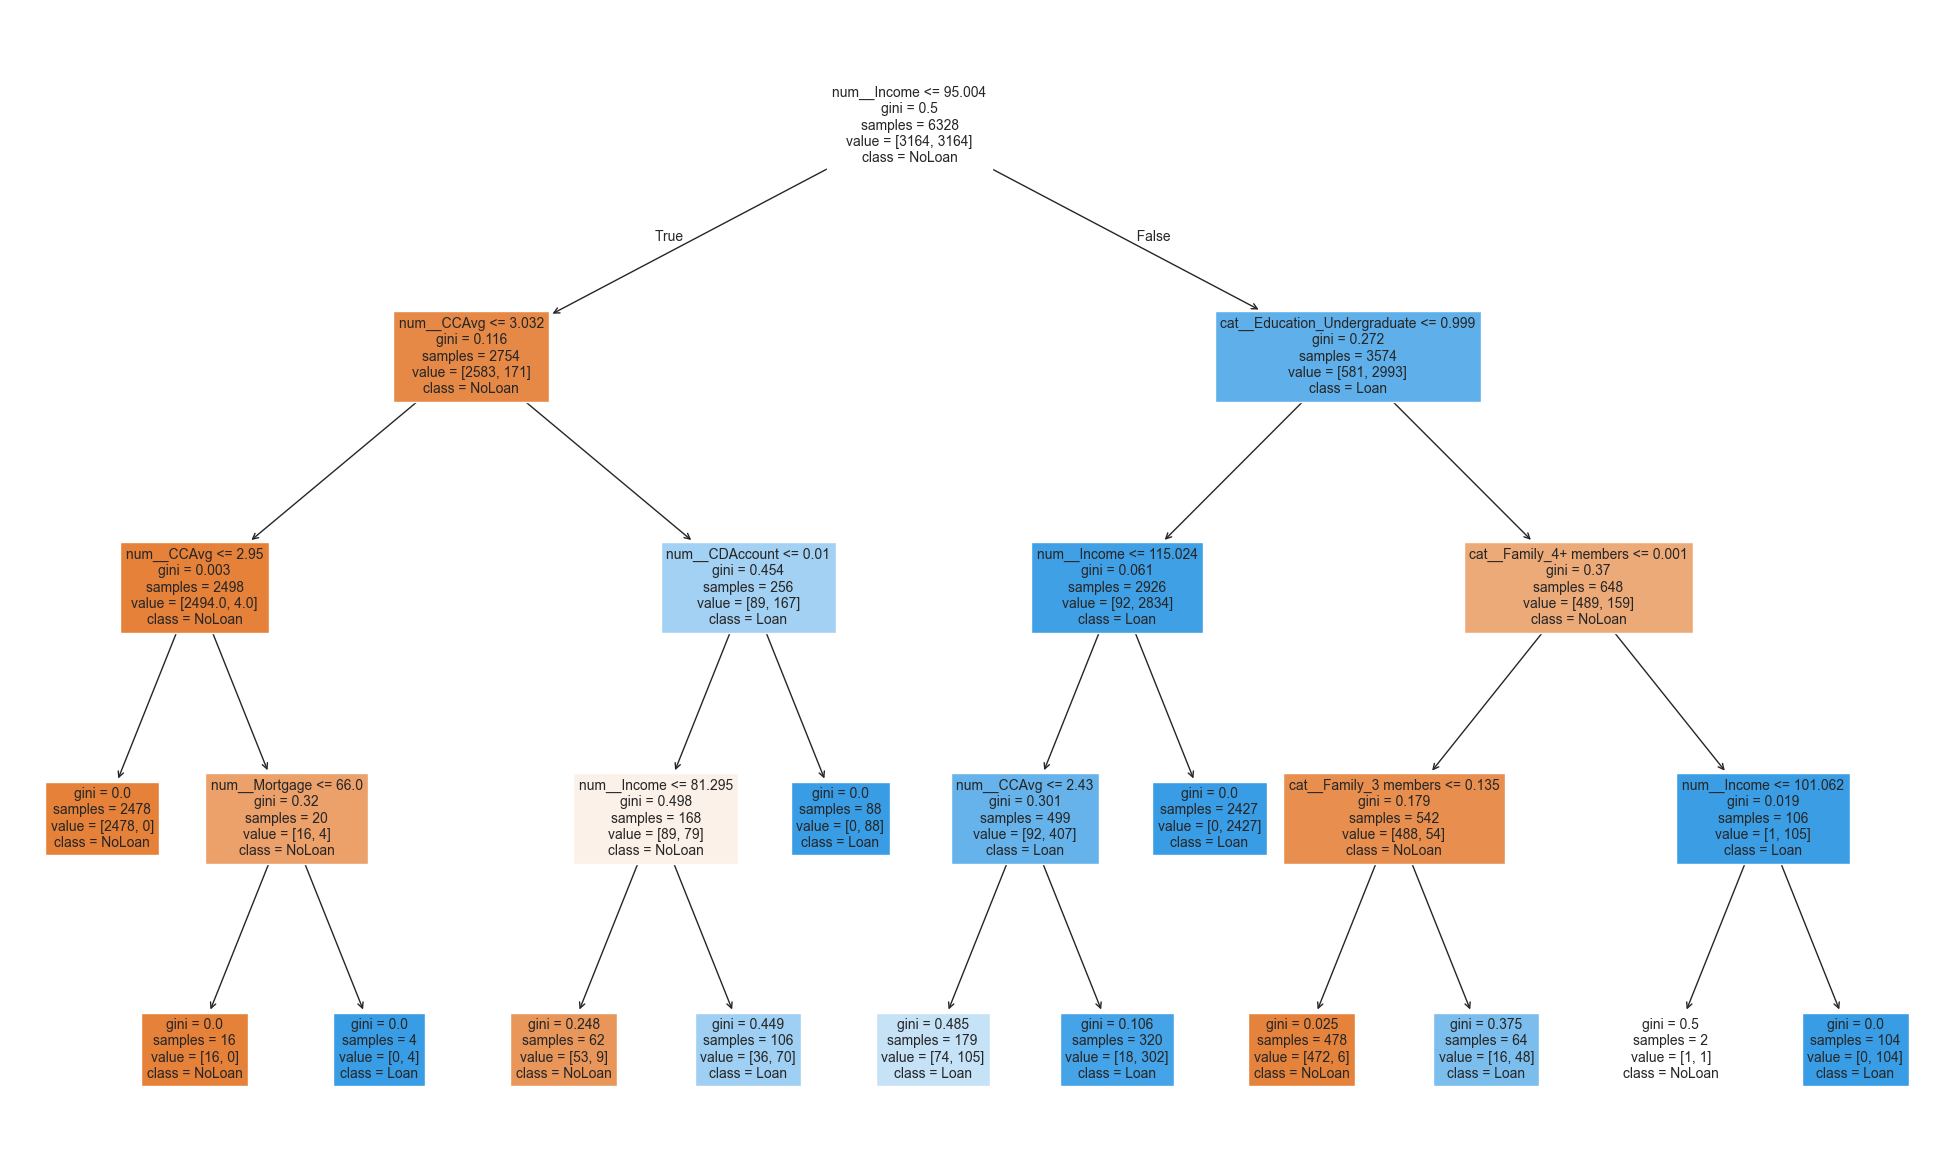

In [17]:
tree_limited = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    ccp_alpha=0,
    random_state=12
)

tree_limited.fit(X_train_smoted, Y_train_smoted)

plt.figure(figsize=(25,15))
plot_tree(tree_limited, filled=True, fontsize=10, feature_names=preprocessor.get_feature_names_out(),
          class_names=["NoLoan", "Loan"])
plt.show()

### **Step 5: Assessing Variable Importance in the Deep Tree**

After training a decision tree, it is essential to **quantify which predictors contribute most** to the model’s decisions. This step computes and visualizes **variable importance** using the deep, unpruned tree (`tree_deep`).

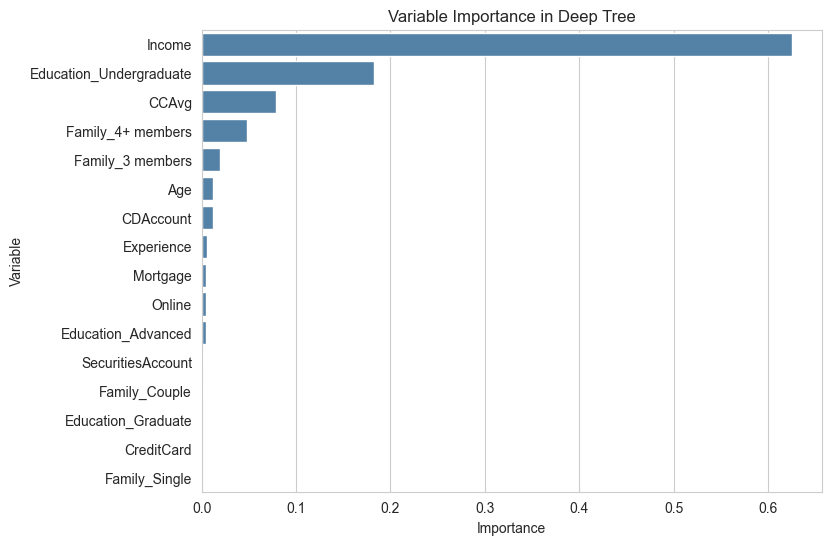

In [18]:
# Calculate variable importance from the deep decision tree
varimp_tree = tree_deep.feature_importances_

# To extract the name of the most important variables we have to extract the name of the categorical columns, because X_train_smoted is 
# registered as a numpy array
ohe = preprocessor.named_transformers_['cat']
cat_feat_names = ohe.get_feature_names_out(categorical_cols) # categorical_cols is the method we applied to identify the categorcial columns

# Combine them with originals numeric columns
feat_names = list(cat_feat_names) + list(numeric_cols)

# Convert the importance object to a dataframe and sort it
importance_df = pd.DataFrame({
    "Variable": feat_names,
    "Importance": varimp_tree
}).sort_values("Importance", ascending=False)

#Creat a horizontal bar chart
plt.figure(figsize=(8,6))
sns.barplot(data=importance_df, x="Importance", y="Variable", color="steelblue")
plt.title("Variable Importance in Deep Tree")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

### **Step 6: Prune the Tree**
A **deep decision tree** captures detailed patterns in training data but often **overfits**, leading to poor generalization on unseen data. **Pruning** is the process of simplifying the tree by removing weak or unnecessary splits, striking a balance between accuracy and interpretability.

When pruning a tree, we use the **complexity parameter (CP)** to control model size:

- Lower `ccp_alphas` → more splits → deeper, more complex tree
- Higher `ccp_alphas` → fewer splits → shallower, simpler tree

#### **1. Print the ccp_alphas Table:**

In [19]:
from sklearn.model_selection import cross_val_score

# Get the pruning curve 
path = tree_deep.cost_complexity_pruning_path(X_train_smoted, Y_train_smoted)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Train trees with diferents alphas
clfs =[]
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train_smoted, Y_train_smoted)
    clfs.append(clf)

# Evaluate with cross-validation
nsplit = [clf.tree_.node_count - clf.tree_.n_leaves for clf in clfs]
cv_scores_all = [cross_val_score(clf, X_train_smoted, Y_train_smoted, cv=5) for clf in clfs]
cv_means = [scores.mean() for scores in cv_scores_all]
cv_stds = [scores.std() for scores in cv_scores_all]

# Create a report
results = pd.DataFrame({
    'ccp_alpha': ccp_alphas,
    "nsplit": nsplit,
    "rel_error": impurities/impurities[0], # it is similar to rel_error, in python it is known as impurities
    "xerror": 1 - np.array(cv_means),
    "xstd": cv_stds
}).sort_values("nsplit", ascending=True)

results

,ccp_alpha,nsplit,rel_error,xerror,xstd
41,0.295533,0,180.146408,0.351126,0.182494
40,0.087692,1,73.667956,0.115204,0.007393
39,0.031078,2,42.073157,0.063526,0.022482
38,0.022243,3,30.876048,0.049619,0.018704
37,0.009701,4,22.862195,0.037768,0.011600
36,0.005122,5,19.366850,0.038873,0.013698
35,0.004537,6,17.521271,0.033659,0.007858
34,0.004448,8,14.251763,0.032079,0.009123
33,0.003282,9,12.649352,0.025916,0.004530
32,0.003053,10,11.466893,0.024967,0.005528


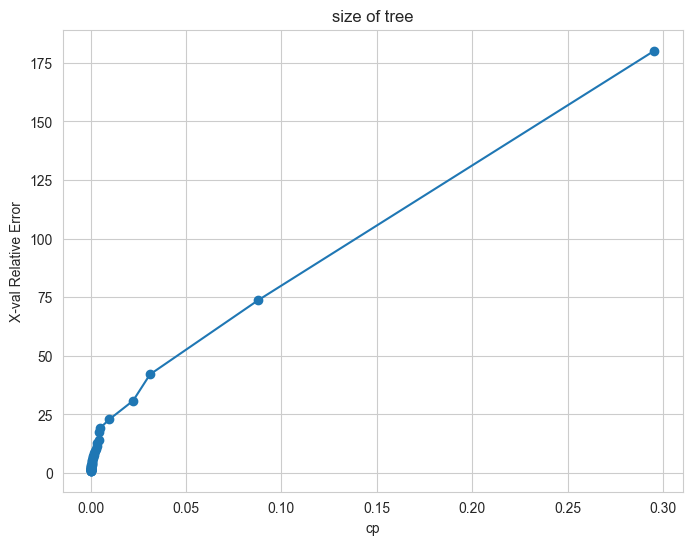

In [20]:
plt.figure(figsize=(8,6))
plt.plot(results['ccp_alpha'], results['rel_error'], marker='o')
plt.title("size of tree")
plt.xlabel("cp")
plt.ylabel("X-val Relative Error")
plt.show()

#### **3. Select the Optimal CP Using the 1-SE Rule**

In [21]:
# Find the minimum error from the cross-validation
min_xerror = results['xerror'].min()

# Find the standard desviation
min_xstd = results.loc[results['xerror'].idxmin(), "xstd"]

# Find the simplest tree using 1-SE Rule
mask = results['xerror'] <= min_xerror + min_xstd
cp_1se = results.loc[mask].sort_values("nsplit").iloc[0]
cp_1se = cp_1se['ccp_alpha']

print("Selected CP (1-SE rule):", cp_1se)

Selected CP (1-SE rule): 0.0020529907137938953


#### **4. Prune the tree**
After identifying the optimal complexity parameter (`cp_1se`), we now prune the fully grown tree to improve interpretability and avoid overfitting.

In [22]:
# Prune the tree using the selected 1-SE rule:
tree_pruned = DecisionTreeClassifier(criterion='gini', ccp_alpha=cp_1se, random_state=123)
tree_pruned.fit(X_train_smoted, Y_train_smoted)

# Count number of terminal nodes:
n_leaves = tree_pruned.tree_.n_leaves
print("Number of terminal nodes: ", n_leaves)

Number of terminal nodes:  13


In [23]:
# Get the index of the variables used:
idx1 = tree_pruned.tree_.feature[tree_pruned.tree_.feature != -2]

# Get preprocessor names:
pre_proc1 = preprocessor.get_feature_names_out()

# NAmes of the variables used:
split1 = pre_proc1[idx1]

# Calculate the number of variables:
num_var1 = len(np.unique(split1))

print(f"Number of variables used: {num_var1}")
print(f"Names of the variables used: {np.unique(split1)}")

Number of variables used: 7
Names of the variables used: ['cat__Education_Undergraduate' 'cat__Family_3 members'
 'cat__Family_4+ members' 'num__Age' 'num__CCAvg' 'num__CDAccount'
 'num__Income']


In this case:
- The pruned tree has **18 terminal nodes** (Number of leaf nodes = nsplit + 1)
- **8 variables** were retained

This confirms that the pruned tree eliminates redundant or low-value features, retaining only the most informative predictors.

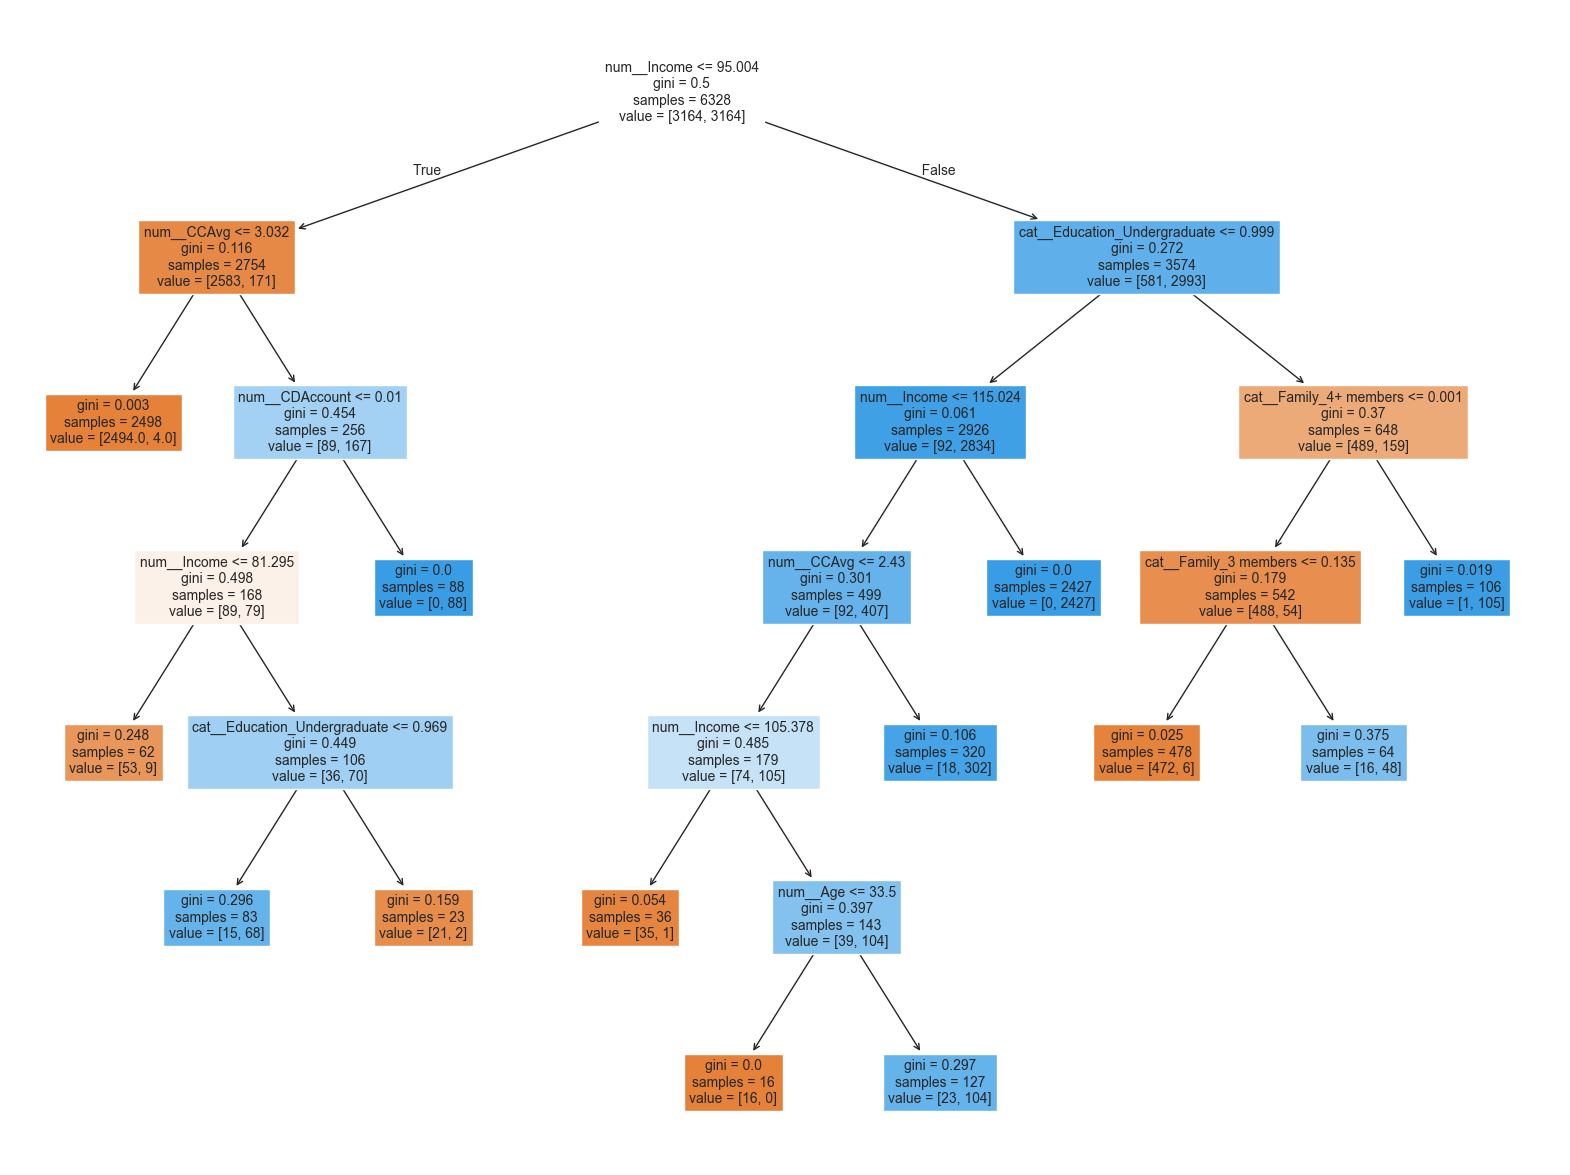

In [24]:
# Visualize the pruned tree
plt.figure(figsize=(20,15))
plot_tree(tree_pruned, filled=True, fontsize=10, feature_names=preprocessor.get_feature_names_out())
plt.show()

**Interpretation**

- The **1-SE pruned tree** is significantly smaller than the fully grown tree, yet maintains high predictive value.
- **Key variables** like `Income`, `CCAvg`, and `Education` remain central, while less impactful variables are removed.
- The pruned tree strikes a balance between **interpretability and performance**, making it better suited for decision-making and presentation.

#### Bonus: Compare 1-SE Rule vs. Min-xerror Pruning

To further explore pruning strategies, let’s compare the tree pruned with the **minimum xerror** strategy and the one pruned using the **1-SE rule.**

In [26]:
# Minimum xerror strategy
cp_min = results.loc[results['xerror'].idxmin(), "ccp_alpha"]
cp_min

np.float64(0.00034212363202907123)

In [34]:
tree_min = DecisionTreeClassifier(criterion='gini', 
                                  min_samples_split=10,
                                  ccp_alpha=cp_min, 
                                  random_state=42)
tree_min.fit(X_train_smoted, Y_train_smoted)

# 1-SE rule strategy
min_xerror1 = results['xerror'].min()
se = results.loc[results['xerror'].idxmin(), 'xstd']
threshold = min_xerror1 + se
cp_1se1 = results[results['xerror'] <= threshold]['ccp_alpha'].iloc[0]
cp_1se1

np.float64(0.0020529907137938953)

In [38]:
tree_1se = DecisionTreeClassifier(
    criterion='gini',
    min_samples_split=10,
    ccp_alpha=cp_1se1,
    random_state=42
)
tree_1se.fit(X_train_smoted, Y_train_smoted)

# Compare number of leaves and variables in each tree
print(f"Deep tree: {sum(tree_deep.tree_.children_left == -1)}")
print(f"Min xerror tree: {sum(tree_min.tree_.children_left == -1)}")
print(f"1-SE tree: {sum(tree_1se.tree_.children_left == -1)}")

Deep tree: 56
Min xerror tree: 33
1-SE tree: 13


The **1-SE tree is the simplest**, sacrificing only a few splits while likely retaining most predictive power.

In [47]:
pre_proc_tree = preprocessor.get_feature_names_out()

idx_deep = tree_deep.tree_.feature[tree_deep.tree_.feature != -2]
split_deep = pre_proc_tree[idx_deep]
print(f"Variables used in Deep Tree:\n{np.unique(split_deep)}")

Variables used in Deep Tree:
['cat__Education_Advanced' 'cat__Education_Graduate'
 'cat__Education_Undergraduate' 'cat__Family_3 members'
 'cat__Family_4+ members' 'cat__Family_Couple' 'num__Age' 'num__CCAvg'
 'num__CDAccount' 'num__CreditCard' 'num__Experience' 'num__Income'
 'num__Mortgage' 'num__Online' 'num__SecuritiesAccount']


In [46]:
idx_min = tree_min.tree_.feature[tree_min.tree_.feature != -2]
split_min = pre_proc_tree[idx_min]
print(f"Variables used in Min xerror Tree:\n{np.unique(split_min)}")

Variables used in Min xerror Tree:
['cat__Education_Advanced' 'cat__Education_Undergraduate'
 'cat__Family_3 members' 'cat__Family_4+ members' 'cat__Family_Couple'
 'num__Age' 'num__CCAvg' 'num__CDAccount' 'num__Experience' 'num__Income'
 'num__Mortgage' 'num__Online']


In [45]:
idx_1se = tree_1se.tree_.feature[tree_1se.tree_.feature != -2]
split_1se = pre_proc_tree[idx_1se]
print(f"Variables used in 1-SE Tree:\n{np.unique(split_1se)}")

Variables used in 1-SE Tree:
['cat__Education_Undergraduate' 'cat__Family_3 members'
 'cat__Family_4+ members' 'num__Age' 'num__CCAvg' 'num__CDAccount'
 'num__Income']


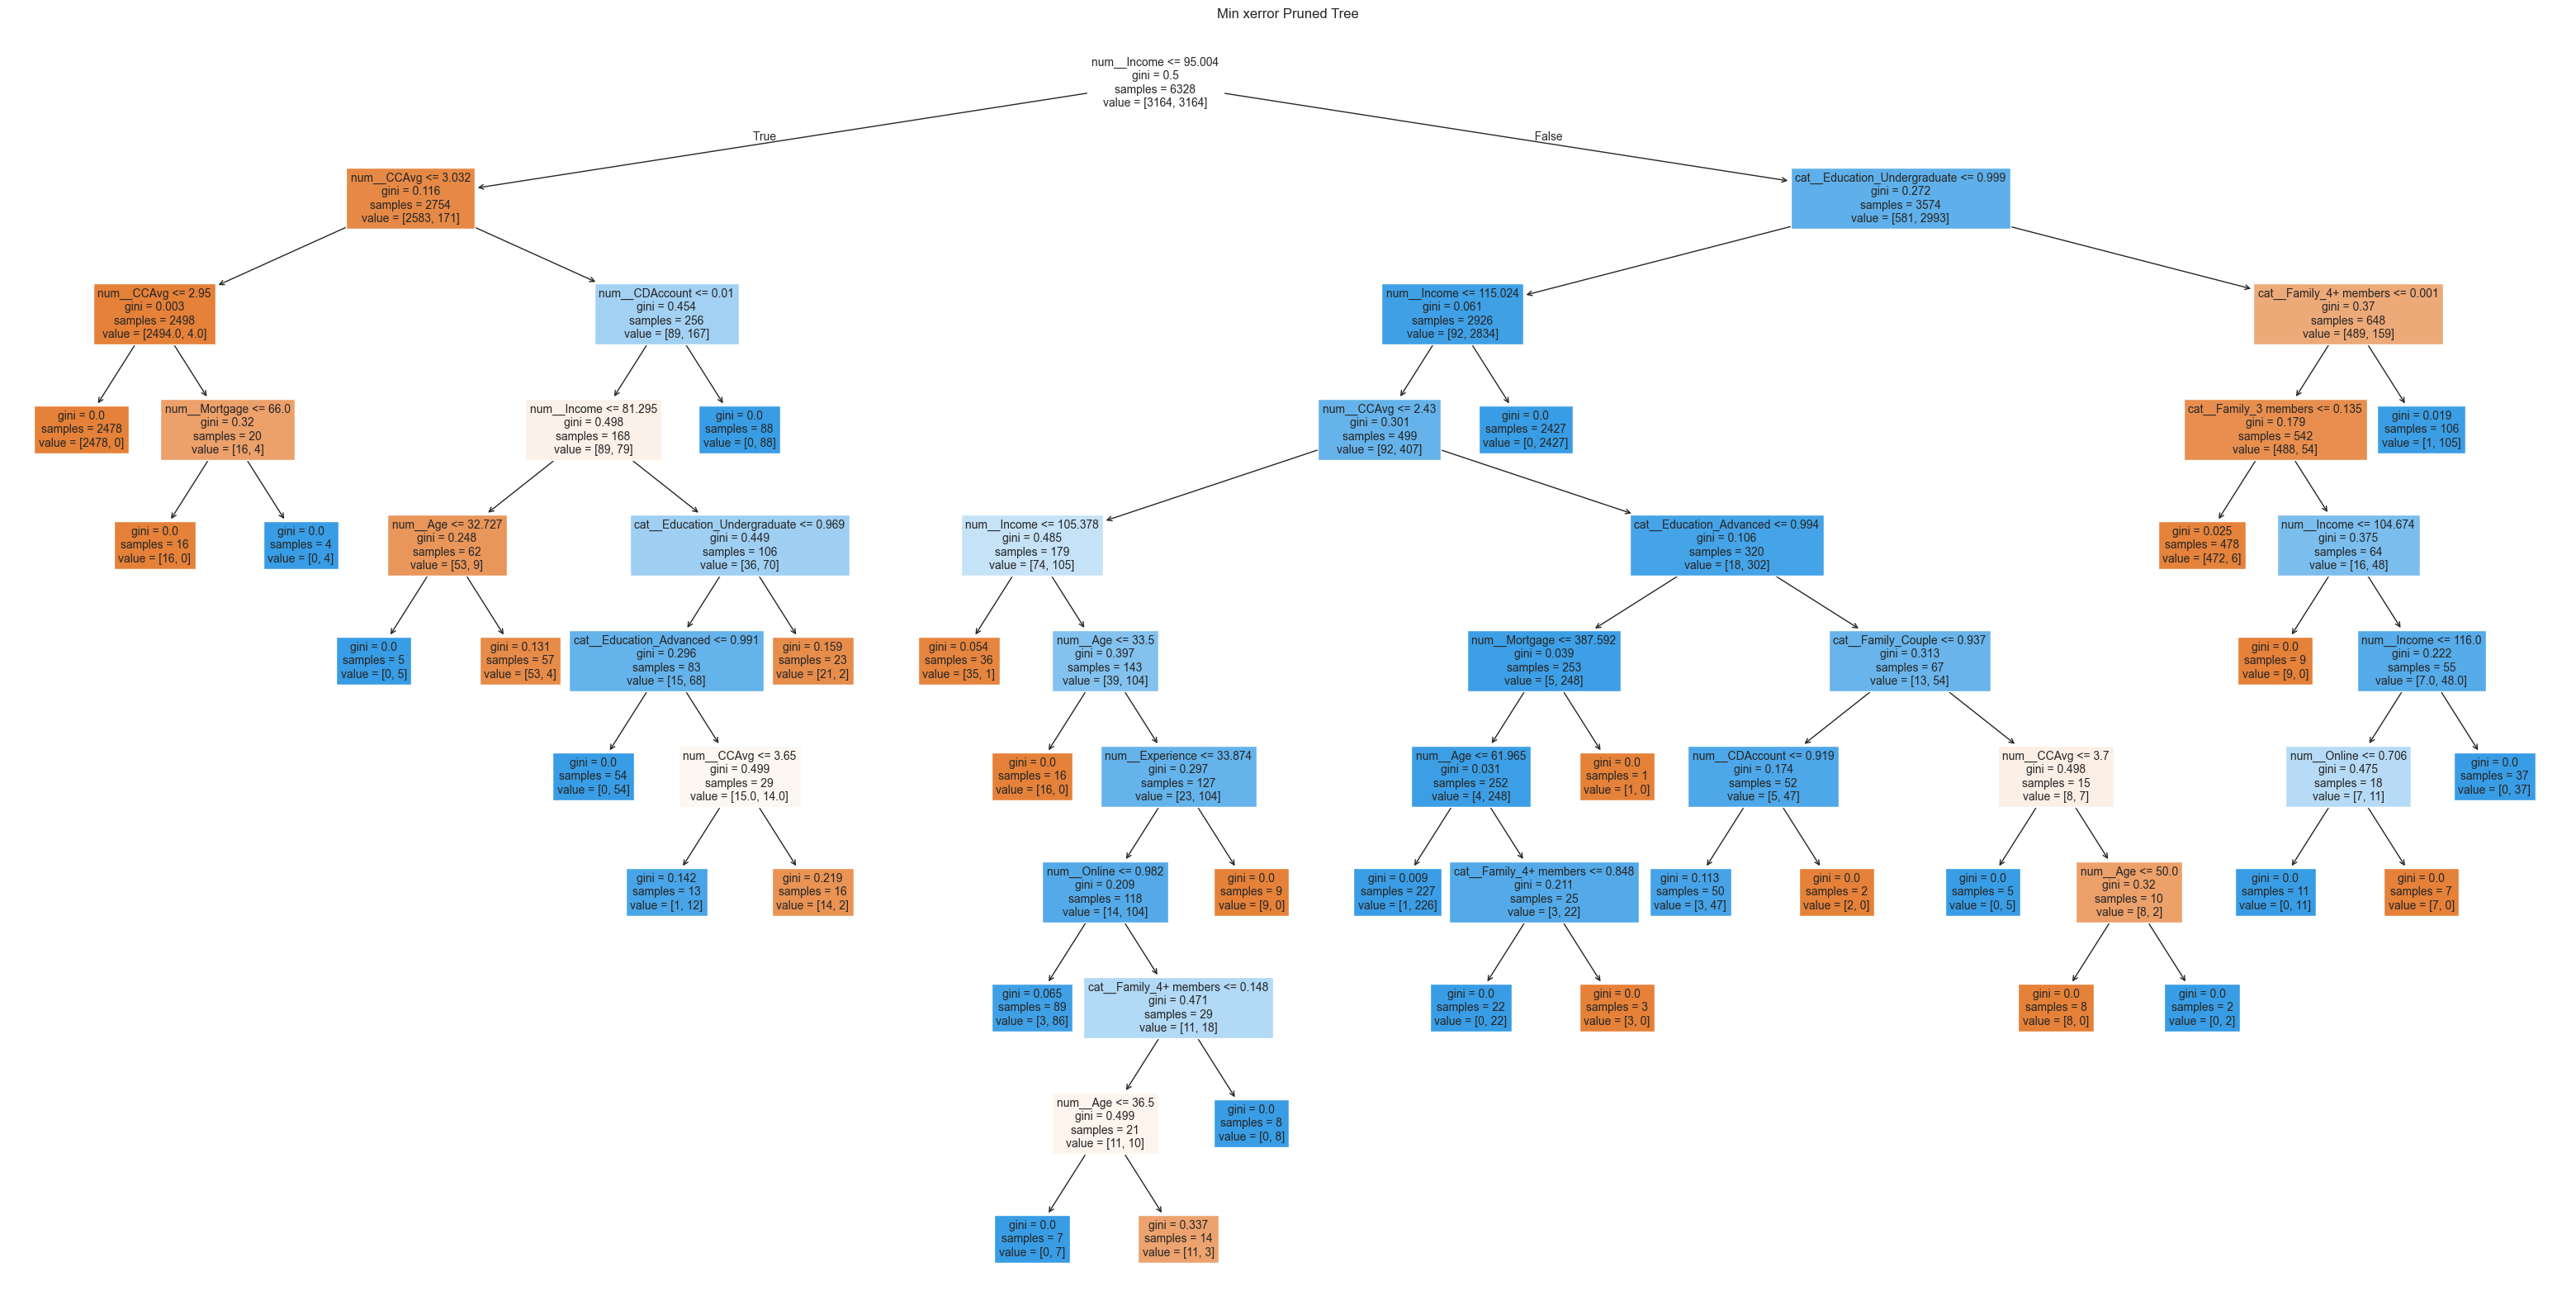

In [54]:
plt.figure(figsize=(40,20))
plot_tree(tree_min, filled=True, fontsize=10, feature_names=preprocessor.get_feature_names_out())
plt.title("Min xerror Pruned Tree")
plt.show()

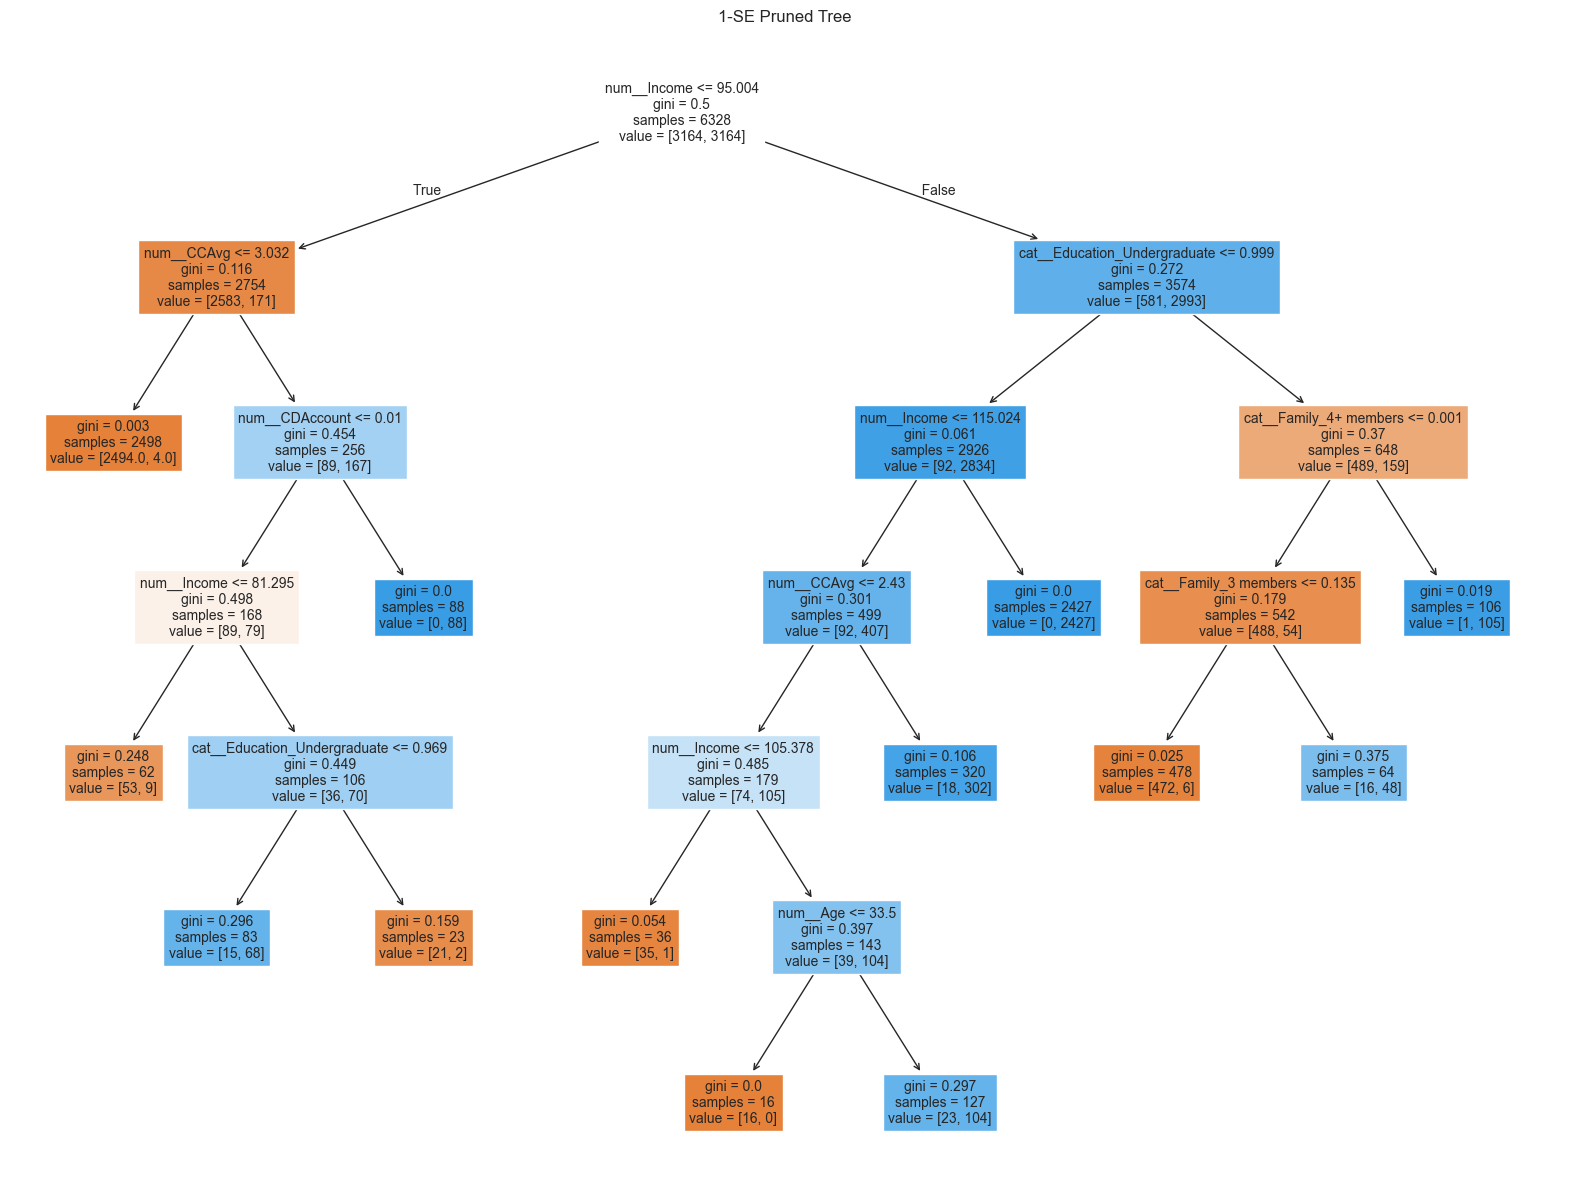

In [53]:
plt.figure(figsize=(20,15))
plot_tree(tree_1se, filled=True, fontsize=10, feature_names=preprocessor.get_feature_names_out())
plt.title("1-SE Pruned Tree")
plt.show()